In [46]:
# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("../input"))

# Any results you write to the current directory are saved as output.

['bank-additional-names.txt', 'bank-additional-full.csv']


Підключіть необхідні бібліотеки.

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, kendalltau,f_oneway
sns.set(rc={'figure.figsize':(10, 8)}); # you can change this if needed

In [67]:
df = pd.read_csv('../input/bank-additional-full.csv', sep=';')

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
age               41188 non-null int64
job               41188 non-null object
marital           41188 non-null object
education         41188 non-null object
default           41188 non-null object
housing           41188 non-null object
loan              41188 non-null object
contact           41188 non-null object
month             41188 non-null object
day_of_week       41188 non-null object
duration          41188 non-null int64
campaign          41188 non-null int64
pdays             41188 non-null int64
previous          41188 non-null int64
poutcome          41188 non-null object
emp.var.rate      41188 non-null float64
cons.price.idx    41188 non-null float64
cons.conf.idx     41188 non-null float64
euribor3m         41188 non-null float64
nr.employed       41188 non-null float64
y                 41188 non-null object
dtypes: float64(5), int64(5), object(11)
memory usa

In [50]:
df.nunique()

age                 78
job                 12
marital              4
education            8
default              3
housing              3
loan                 3
contact              2
month               10
day_of_week          5
duration          1544
campaign            42
pdays               27
previous             8
poutcome             3
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          316
nr.employed         11
y                    2
dtype: int64

Preprocesing


In [68]:
df['y'] = df['y'].map({"no":0,"yes":1})
df['contact'] = df['contact'].map({"cellular":0,"telephone":1})
df1 = pd.get_dummies(df, columns=['job','marital','education','default','housing','loan','month','day_of_week','poutcome'])
df1.head(6).T

,0,1,2,3,4,5
age,56.000,57.000,37.000,40.000,56.000,45.000
contact,1.000,1.000,1.000,1.000,1.000,1.000
duration,261.000,149.000,226.000,151.000,307.000,198.000
campaign,1.000,1.000,1.000,1.000,1.000,1.000
pdays,999.000,999.000,999.000,999.000,999.000,999.000
previous,0.000,0.000,0.000,0.000,0.000,0.000
emp.var.rate,1.100,1.100,1.100,1.100,1.100,1.100
cons.price.idx,93.994,93.994,93.994,93.994,93.994,93.994
cons.conf.idx,-36.400,-36.400,-36.400,-36.400,-36.400,-36.400
euribor3m,4.857,4.857,4.857,4.857,4.857,4.857


In [52]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 63 columns):
age                              41188 non-null int64
contact                          41188 non-null int64
duration                         41188 non-null int64
campaign                         41188 non-null int64
pdays                            41188 non-null int64
previous                         41188 non-null int64
emp.var.rate                     41188 non-null float64
cons.price.idx                   41188 non-null float64
cons.conf.idx                    41188 non-null float64
euribor3m                        41188 non-null float64
nr.employed                      41188 non-null float64
y                                41188 non-null int64
job_admin.                       41188 non-null uint8
job_blue-collar                  41188 non-null uint8
job_entrepreneur                 41188 non-null uint8
job_housemaid                    41188 non-null uint8
job_management   

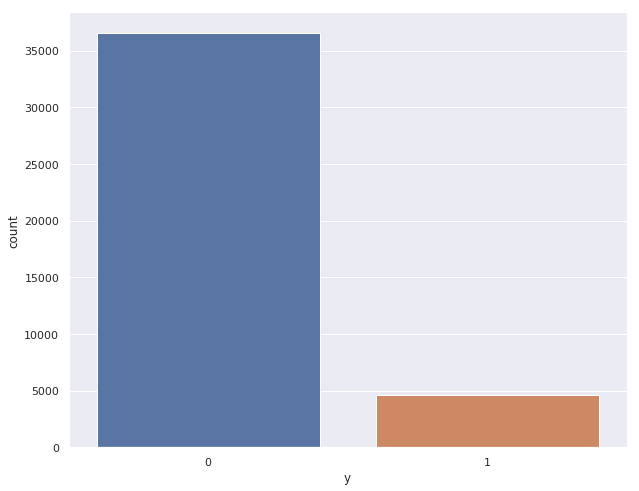

In [53]:
sns.countplot(x="y", data=df);

In [70]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(df1.drop('y', axis=1),
                                                      df1['y'],
                                                      test_size=0.25,
                                                      random_state=42)

3. Побудувати одну з лінійних моделей машинного навчання (лінійну регресію або логістичну регресію, залежно від вашого варіанту). Оцінити якість моделі на тестових даних за допомогою декількох метрик. 

Це типова проблема двійкової класифікації. Тому ми розглянемо саме логістичну регресію.

In [71]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_valid)

from sklearn.metrics import accuracy_score
print(accuracy_score(y_valid, y_pred))

/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


0.910944935418083


Можна сконструювати наступні три метрики, кожна з яких краще представляє результати класифікації.  Це Precision, Recall та  F-оцінка (f1_score).  • Precision показує, наскільки можна «довіряти» моделі, якщо вона показала клас 1;
 • Recall показує, наскільки добре модель здатна знайти клас 1;
 • F1: середнє гармонічне між Precision та Recall.

In [72]:
from sklearn.metrics import precision_score, recall_score, f1_score
print('Precision:', precision_score(y_valid, y_pred))
print('Recall:', recall_score(y_valid, y_pred))
print('F1 score:', f1_score(y_valid, y_pred))

Precision: 0.6666666666666666
Recall: 0.409366869037294
F1 score: 0.5072541644277271


У нашому прикладі ми і хочемо якомога менше помилкових спрацьовувань і важливо звести до мінімуму промахи класу 1, тому беремо гармонічне між ними f1-score.

Застосувати декілька типів регуляризації (Ridge, Lasso, ElasticNet), налаштувати гіперпараметри моделей, побудувати валідаційні криві. 


Гіперпараметр C>0 відіграє роль зворотної сили регуляризації.  Чим більший С, тим менший «штраф» за збільшення ваги моделі.  І навпаки, чим менший C, тим більший ефект регуляризації.


 Налаштуємо параметр C (сила регуляризації) для кожного типу регуляризації.

In [57]:
# Ridge
from sklearn.linear_model import Ridge
log_reg = LogisticRegression(solver='liblinear')
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_valid)

print('F1 score:', f1_score(y_valid, y_pred, average = "weighted"))

F1 score: 0.9013553131957638


In [58]:
from sklearn.model_selection import GridSearchCV

C_values = {'C': np.logspace(-3, 3, 10)}
logreg_grid = GridSearchCV(log_reg, C_values, cv=5, scoring='f1')
logreg_grid.fit(X_train, y_train)

GridSearchCV(cv=5, error_score='raise-deprecating',
       estimator=LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='warn',
          n_jobs=None, penalty='l2', random_state=None, solver='liblinear',
          tol=0.0001, verbose=0, warm_start=False),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'C': array([1.00000e-03, 4.64159e-03, 2.15443e-02, 1.00000e-01, 4.64159e-01,
       2.15443e+00, 1.00000e+01, 4.64159e+01, 2.15443e+02, 1.00000e+03])},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring='f1', verbose=0)

In [59]:
print(logreg_grid.best_params_)
print(logreg_grid.best_score_)

{'C': 10.0}
0.4995870792204044


/opt/conda/lib/python3.6/site-packages/sklearn/utils/deprecation.py:125: FutureWarning: You are accessing a training score ('split0_train_score'), which will not be available by default any more in 0.21. If you need training scores, please set return_train_score=True
  warnings.warn(*warn_args, **warn_kwargs)
/opt/conda/lib/python3.6/site-packages/sklearn/utils/deprecation.py:125: FutureWarning: You are accessing a training score ('split1_train_score'), which will not be available by default any more in 0.21. If you need training scores, please set return_train_score=True
  warnings.warn(*warn_args, **warn_kwargs)
/opt/conda/lib/python3.6/site-packages/sklearn/utils/deprecation.py:125: FutureWarning: You are accessing a training score ('split2_train_score'), which will not be available by default any more in 0.21. If you need training scores, please set return_train_score=True
  warnings.warn(*warn_args, **warn_kwargs)
/opt/conda/lib/python3.6/site-packages/sklearn/utils/deprecation.py

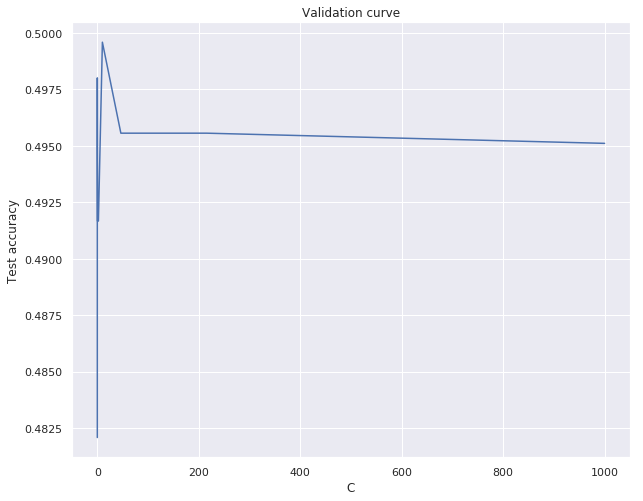

In [60]:
results_df = pd.DataFrame(logreg_grid.cv_results_)
plt.plot(results_df['param_C'], results_df['mean_test_score'])

plt.xlabel('C')
plt.ylabel('Test accuracy')
plt.title('Validation curve')
plt.show()

In [73]:
# Lasso
log_reg1 = LogisticRegression(max_iter=1000, solver='liblinear', penalty='l1')
log_reg1.fit(X_train, y_train)
y_pred = log_reg1.predict(X_valid)

print('F1 score:', f1_score(y_valid, y_pred, average = "weighted"))

F1 score: 0.9028869526862383


In [ ]:
from sklearn.model_selection import GridSearchCV

C_values = {'C': np.logspace(-3, 3, 10)}
logreg1_grid = GridSearchCV(log_reg1, C_values, cv=5, scoring='f1')
logreg1_grid.fit(X_train, y_train)

In [ ]:
print(logreg1_grid.best_params_)
print(logreg1_grid.best_score_)

In [ ]:
results_df = pd.DataFrame(logreg1_grid.cv_results_)
plt.plot(results_df['param_C'], results_df['mean_test_score'])

plt.xlabel('C')
plt.ylabel('Test accuracy')
plt.title('Validation curve')
plt.show()

In [63]:
#elasticnet
log_reg2 = LogisticRegression(max_iter=1000, solver='liblinear', penalty='elasticnet')
log_reg2.fit(X_train, y_train)
y_pred = log_reg2.predict(X_valid)

print('F1 score:', f1_score(y_valid, y_pred, average = "weighted"))

ValueError: Logistic Regression supports only penalties in ['l1', 'l2'], got elasticnet.

In [ ]:
C_values = {'C': np.logspace(-3, 3, 10)}
logreg2_grid = GridSearchCV(log_reg2, C_values, cv=5, scoring='f1')
logreg2_grid.fit(X_train, y_train)

In [ ]:
print(logreg2_grid.best_params_)
print(logreg2_grid.best_score_)

In [ ]:
results_df = pd.DataFrame(logreg2_grid.cv_results_)
plt.plot(results_df['param_C'], results_df['mean_test_score'])

plt.xlabel('C')
plt.ylabel('Test accuracy')
plt.title('Validation curve')
plt.show()

In [ ]:
best_scores = [logreg_grid.best_score_, logreg1_grid.best_score_, logreg2_grid.best_score_]
model_names = ['Lasso', 'Ridge', 'ElasticNet']

plt.figure(figsize=(8, 6))
plt.show()

for i in range(len(best_scores)):
    print(f"{model_names[i]} = {best_scores[i]}")